In [53]:
# estas son las librerías que vamos a usar para el análisis de datos y visualización de estos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos el dataset de csv a un dataframe de pandas
df = pd.read_csv("train.csv") 

# Copia del dataset para usar este y dejar el original
df_limpio = df.copy()

# aquí limpio nulos y también reemplazo los 0 por la mediana en estas columnas
cols_mediana = ["bathrooms", "bedrooms", "beds", "review_scores_rating"]

for col in cols_mediana:
    mediana = df_limpio[col].median()
    df_limpio[col] = df_limpio[col].replace(0, np.nan).fillna(mediana)

# Verificar si hay valores nulos
df_limpio.isnull().sum()

id                            0
log_price                     0
property_type                 0
room_type                     0
amenities                     0
accommodates                  0
bathrooms                     0
bed_type                      0
cancellation_policy           0
cleaning_fee                  0
city                          0
description                   0
first_review              15864
host_has_profile_pic        188
host_identity_verified      188
host_response_rate        18299
host_since                  188
instant_bookable              0
last_review               15827
latitude                      0
longitude                     0
name                          0
neighbourhood              6872
number_of_reviews             0
review_scores_rating          0
thumbnail_url              8216
zipcode                     966
bedrooms                      0
beds                          0
dtype: int64

Después del proceso de limpieza las variables importantes numericas ya no tiene nulos algunas si pero no son relevantes para el analisis o graficas que se realizaran

Algunas variables categóricas y de texto aún presentan valores faltantes, pero no afectan el análisis actual, ya que no son utilizadas en las visualizaciones principales.

In [54]:
#  esto muestra informacion general del dataframe

df_limpio.info() 

<class 'pandas.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      74111 non-null  int64  
 1   log_price               74111 non-null  float64
 2   property_type           74111 non-null  str    
 3   room_type               74111 non-null  str    
 4   amenities               74111 non-null  str    
 5   accommodates            74111 non-null  int64  
 6   bathrooms               74111 non-null  float64
 7   bed_type                74111 non-null  str    
 8   cancellation_policy     74111 non-null  str    
 9   cleaning_fee            74111 non-null  bool   
 10  city                    74111 non-null  str    
 11  description             74111 non-null  str    
 12  first_review            58247 non-null  str    
 13  host_has_profile_pic    73923 non-null  str    
 14  host_identity_verified  73923 non-null  str    
 

In [55]:
# Estadísticas descriptivas del dataframe
df_limpio.describe()

,id,log_price,accommodates,bathrooms,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds
count,7.411100e+04,74111.000000,74111.000000,74111.000000,74111.000000,74111.000000,74111.000000,74111.000000,74111.000000,74111.000000
mean,1.126662e+07,4.782069,3.155146,1.237299,38.445958,-92.397525,20.900568,94.503434,1.356074,1.709665
std,6.081735e+06,0.717394,2.153589,0.577994,3.080167,21.705322,37.828641,6.943159,0.760538,1.253336
min,3.440000e+02,0.000000,1.000000,0.500000,33.338905,-122.511500,0.000000,20.000000,1.000000,1.000000
25%,6.261964e+06,4.317488,2.000000,1.000000,34.127908,-118.342374,1.000000,93.000000,1.000000,1.000000
50%,1.225415e+07,4.709530,2.000000,1.000000,40.662138,-76.996965,6.000000,96.000000,1.000000,1.000000
75%,1.640226e+07,5.220356,4.000000,1.000000,40.746096,-73.954660,23.000000,99.000000,1.000000,2.000000
max,2.123090e+07,7.600402,16.000000,8.000000,42.390437,-70.985047,605.000000,100.000000,10.000000,18.000000


A partir de las estadísticas descriptivas se observan los siguientes puntos:

El precio tiene una media de 4.78 y una mediana de 4.70, lo que indica que la distribución no es tan alta.
La capacidad promedio de accommodates es de 3 personas y existen propiedades con capacidad de hasta 16 lo que muestra varabilidad.
La mayoría de las propiedades tienen 1 baño, 1 habitación y entre 1 y 2 camas indica que hay mas alojamientos pequeños.
El número de reseñas presenta una gran dispersión  de 0 a 605, lo que muestra que hay popularidad entre varias propiedades.
Las calificaciones son altas en general media de 94.5 lo que indica que las personas estan contentas.

In [56]:
# la mediana para solo numericos
df_limpio.median(numeric_only=True)

id                      1.225415e+07
log_price               4.709530e+00
accommodates            2.000000e+00
bathrooms               1.000000e+00
cleaning_fee            1.000000e+00
latitude                4.066214e+01
longitude              -7.699696e+01
number_of_reviews       6.000000e+00
review_scores_rating    9.600000e+01
bedrooms                1.000000e+00
beds                    1.000000e+00
dtype: float64

La mediana muestra el valor central de cada variable:

El precio tiene una mediana de 4.70, lo que indica el valor típico del mercado.
La capacidad (accommodates) es de 2 personas entonces la mayoría de los alojamientos son pequeños.
La mayoría de las propiedades tienen 1 baño, 1 habitación y 1 cama.
El número de reseñas tiene una mediana de 6 lo que indica que algunas tienen muy pocas reseñas.
La calificación tiene una mediana de 96, reflejando alta satisfacción de los usuarios.

La mediana confirma hay mas alojaminetos pequeños.

Variables que influyen en el precio
las siguientes variables pueden influir en el precio

accommodates: indica la cantidad de personas que puede alojar la propiedad.
bedrooms: el numero de cuartos que tiene la propiedad
bathrooms: número de baños que tiene que ver con la comodidad y tamaño
beds: número de camas disponibles en los cuartos y propiedad
room_type: tipo de alojamiento  que son entero, privado o compartido.
city: la ubicacion de la propiedad puede influir en el precio ya que las casas en algunas ciudades pueden ser mas caras que en otras
Estas variables están relacionadas con el tamaño, capacidad y ubicación de la propiedad, por lo que es probable que tengan mucha influencia en el precio de los airbnbs.


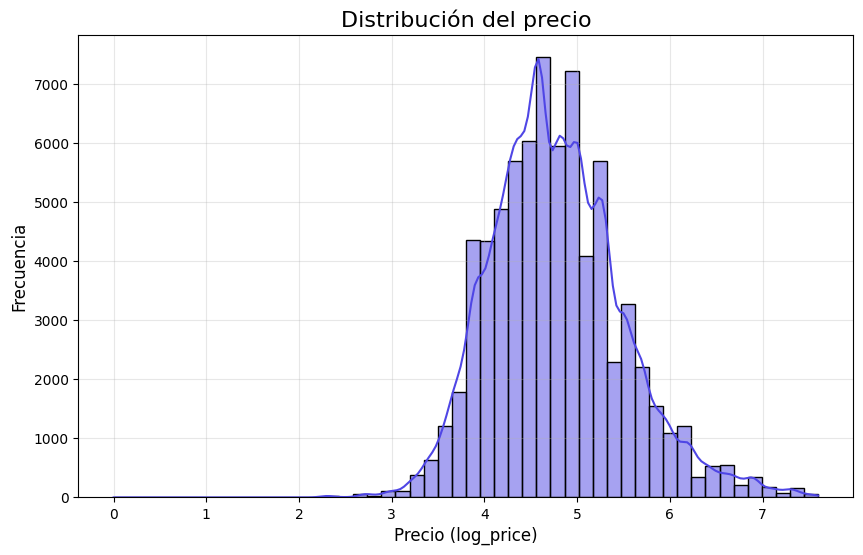

In [57]:
# Histograma de la variable log_price para observar cómo se distribuyen los precios
# Se usa log_price porque la transformación logarítmica facilita ver mejor la forma
# de la distribución y reduce el efecto de valores extremos.
plt.figure(figsize=(10,6))

# bins=50 permite un buen nivel de detalle y kde=True añade una curva de densidad
# para identificar si la distribución se concentra en ciertos rangos de precio.
sns.histplot(df_limpio["log_price"], bins=50, kde=True, color="#4F46E5")

# Título y etiquetas para interpretar claramente la gráfica
plt.title("Distribución del precio", fontsize=16)
plt.xlabel("Precio (log_price)", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)

# La cuadrícula ayuda a comparar visualmente la frecuencia entre intervalos
plt.grid(alpha=0.3)
plt.show()

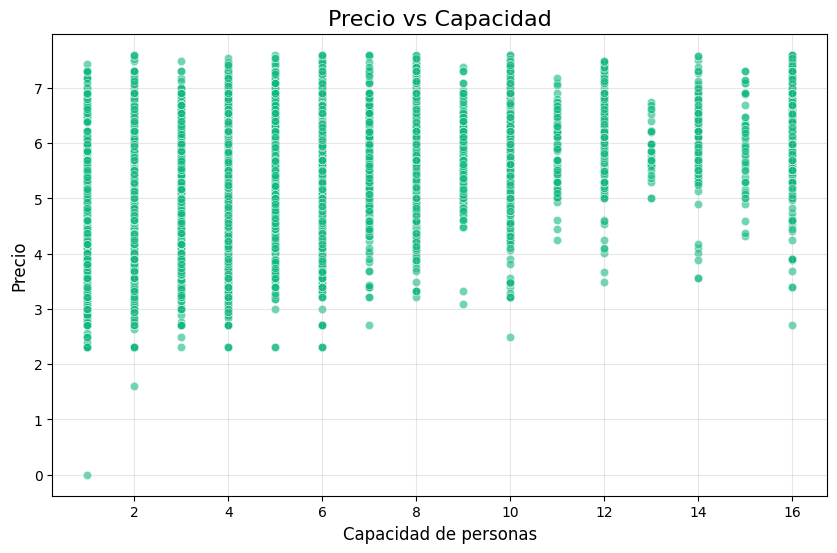

In [58]:
# Gráfica de dispersión para analizar la relación entre capacidad y precio
# Nos permite ver si a mayor capacidad, mayor es el precio del alojamiento
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="accommodates",   # Eje X: capacidad máxima de personas del alojamiento
    y="log_price",      # Eje Y: precio en escala logarítmica para reducir el efecto de valores extremos
    data=df_limpio,     # Usamos el dataframe limpio sin nulos ni valores atípicos
    alpha=0.6,          # Transparencia del 60% para ver la densidad de puntos superpuestos
    color="#10B981"     # Color verde para diferenciarla visualmente de otras gráficas
)

# Título descriptivo que indica claramente qué relación se está analizando
plt.title("Precio vs Capacidad", fontsize=16)

# Etiquetas de los ejes con descripción clara de cada variable
plt.xlabel("Capacidad de personas", fontsize=12)  # Número máximo de huéspedes
plt.ylabel("Precio", fontsize=12)                 # Precio en escala logarítmica

# Cuadrícula suave para facilitar la lectura de valores sin saturar la gráfica
plt.grid(alpha=0.3)
plt.show()

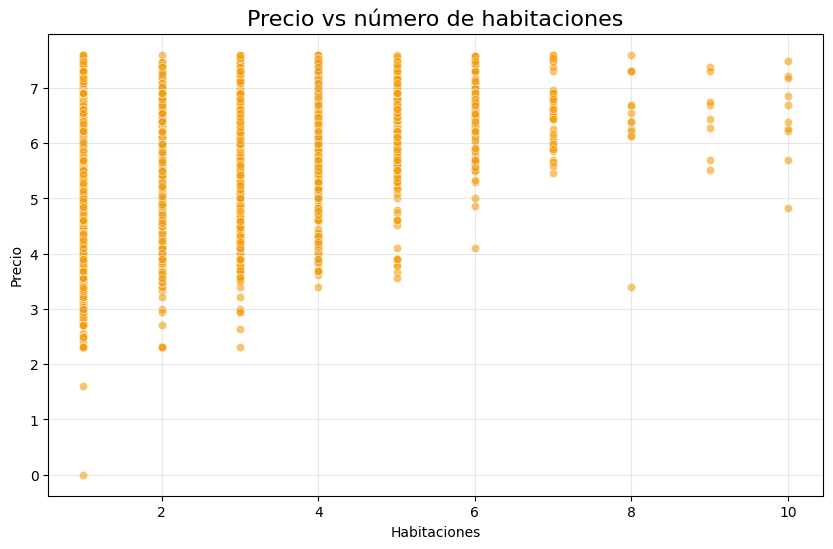

In [59]:
# Gráfica de dispersión para analizar la relación entre número de habitaciones y precio
# Permite identificar si propiedades con más habitaciones tienden a tener precios más altos
plt.figure(figsize=(10, 6))

# Scatterplot con bedrooms en X y log_price en Y
# alpha=0.6 permite ver la densidad de puntos superpuestos sin saturar la gráfica
sns.scatterplot(
    x="bedrooms",       # Eje X: número de habitaciones de la propiedad
    y="log_price",      # Eje Y: precio en escala logarítmica para reducir el efecto de valores extremos
    data=df_limpio,     # Usamos el dataframe limpio sin nulos ni valores atípicos
    alpha=0.6,          # Transparencia del 60% para ver densidad de puntos superpuestos
    color="#F59E0B"     # Color amarillo-naranja para diferenciarla visualmente de otras gráficas
)

# Título descriptivo que indica claramente qué relación se está analizando
plt.title("Precio vs número de habitaciones", fontsize=16)

# Etiquetas de los ejes con descripción clara de cada variable
plt.xlabel("Habitaciones", fontsize=12)   # Número de habitaciones de la propiedad
plt.ylabel("Precio", fontsize=12)         # Precio en escala logarítmica

# Cuadrícula suave para facilitar la lectura de valores sin saturar la gráfica
plt.grid(alpha=0.3)
plt.show()

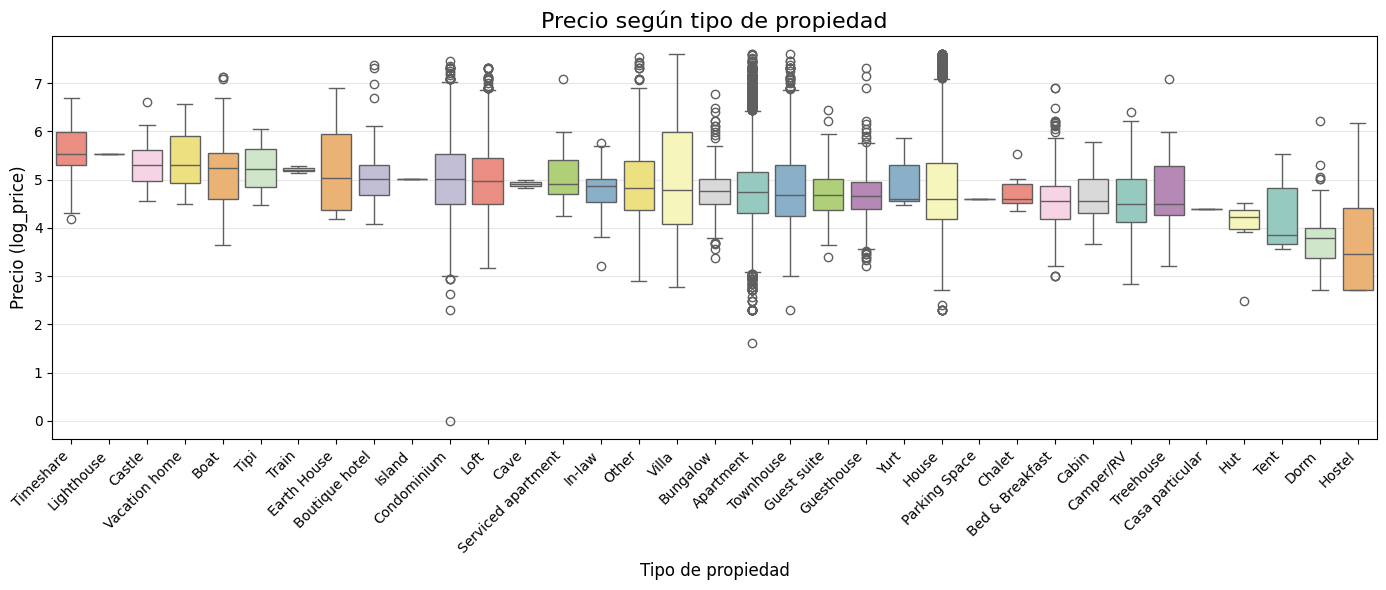

In [60]:
# Boxplot para comparar el precio según el tipo de propiedad
# Permite identificar qué tipos de propiedad tienen precios más altos o más bajos
plt.figure(figsize=(14, 6))

# Ordenamos los tipos de propiedad por la mediana del precio de mayor a menor
# Esto facilita la comparación visual y la identificación de patrones
orden = df_limpio.groupby("property_type")["log_price"].median().sort_values(ascending=False).index

# Boxplot con property_type en X y log_price en Y
# palette="Set3" para usar colores distintos por tipo de propiedad
# hue="property_type" asigna un color único a cada tipo de propiedad
sns.boxplot(
    x="property_type",
    y="log_price",
    data=df_limpio,
    order=orden,        # Orden descendente por mediana de precio
    palette="Set3",     
    hue="property_type",
    legend=False        # Ocultamos la leyenda porque el eje X ya identifica cada tipo
)

# Título descriptivo que indica claramente qué relación se está analizando
plt.title("Precio según tipo de propiedad", fontsize=16)

# Etiquetas de los ejes con descripción clara de cada variable
plt.xlabel("Tipo de propiedad", fontsize=12)
plt.ylabel("Precio (log_price)", fontsize=12)   # Precio en escala logarítmica

# Rotamos las etiquetas del eje X para que sean legibles ya que hay muchos tipos
plt.xticks(rotation=45, ha="right")

# Cuadrícula horizontal suave para facilitar la comparación de precios entre tipos
plt.grid(axis="y", alpha=0.3)

# tight_layout ajusta los márgenes para evitar que las etiquetas se corten
plt.tight_layout()
plt.show()

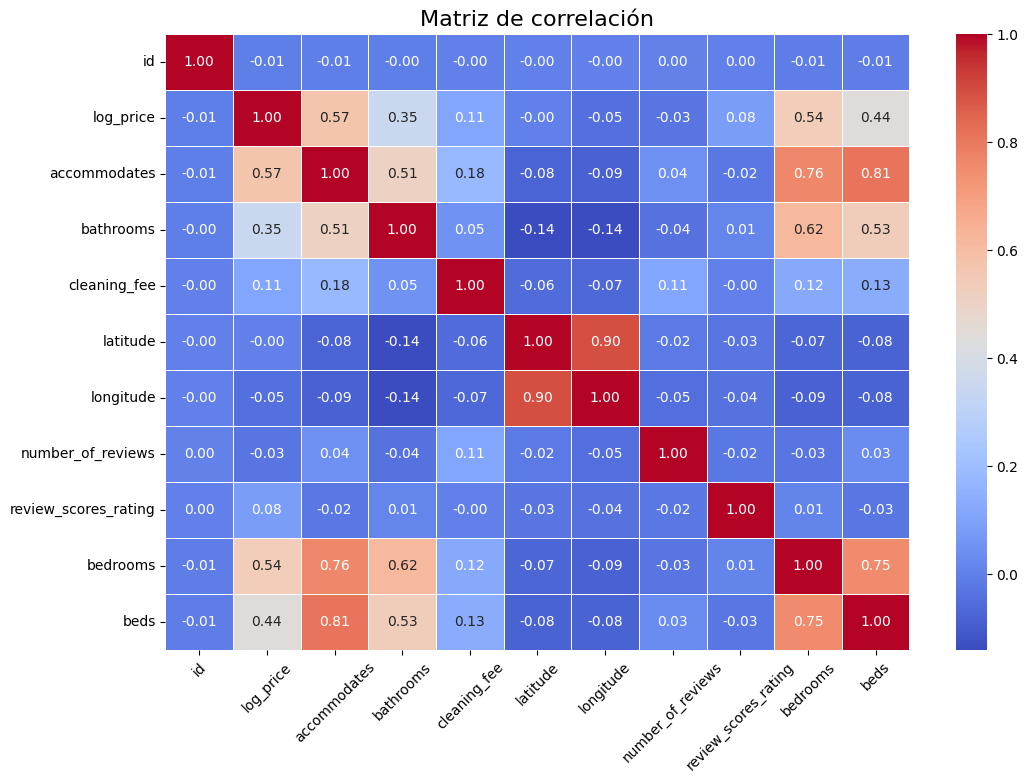

In [61]:
# Calculamos matriz con solo nums
corr = df_limpio.corr(numeric_only=True)

# cambiamos el tamaño 
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    linecolor="white"
)

# Título y formato de etiquetas de los ejes
plt.title("Matriz de correlación", fontsize=16)
plt.xticks(rotation=45)  
plt.yticks(rotation=0)  
plt.show()

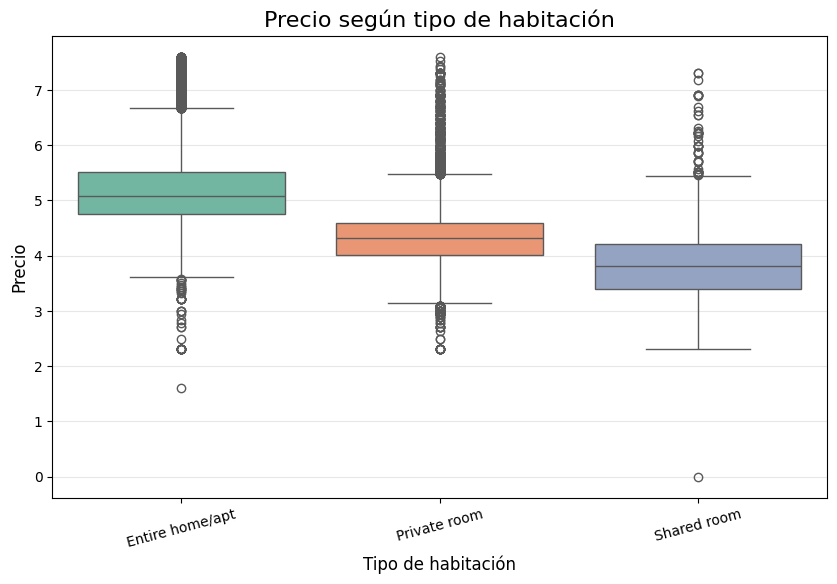

In [ ]:
# Gráfica de caja para comparar el precio según el tipo de habitación
# Justificación: el boxplot permite comparar mediana, dispersión y valores atípicos entre categorías.
plt.figure(figsize=(10, 6))

# Ordenamos los tipos de habitación por la mediana del precio para facilitar la comparación visual
orden_room = (
    df_limpio.groupby("room_type")["log_price"]
    .median()
    .sort_values(ascending=False)
    .index
)

sns.boxplot(
    x="room_type",
    y="log_price",      # Se usa log_price para reducir sesgo por valores extremos
    data=df_limpio,
    order=orden_room,
    palette="Set2"
)

# Título y etiquetas
plt.title("Precio según tipo de habitación", fontsize=16)
plt.xlabel("Tipo de habitación", fontsize=12)
plt.ylabel("Precio (log_price)", fontsize=12)

# Ajustes de formato para legibilidad
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()